In [2]:
import numpy as np
import pandas as pd

df=pd.read_csv("placement.csv")
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


(100, 4)

In [4]:
df=df.iloc[ : ,1: ]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


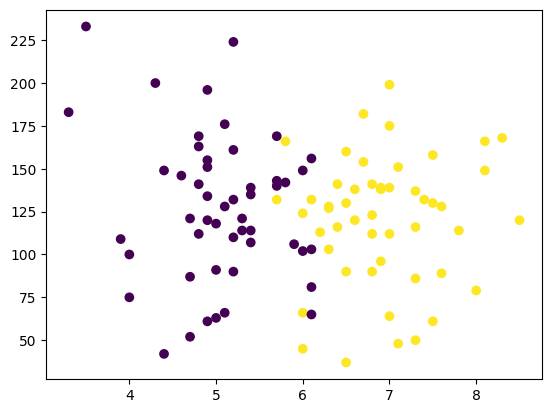

In [5]:
import matplotlib.pyplot as plt

plt.scatter(df['cgpa'],df['iq'],c=df['placement'])


In [6]:
x=df.iloc[:,0:2]
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [7]:
y=df.iloc[:,-1]
y.shape

(100,)

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

x_train

,cgpa,iq
88,4.4,149.0
28,5.2,90.0
93,6.8,112.0
59,4.8,112.0
2,5.3,121.0
...,...,...
47,5.2,161.0
12,5.4,139.0
9,5.1,66.0
69,8.5,120.0


In [11]:
y_train

,placement
88,0
28,0
93,1
59,0
2,0
...,...
47,0
12,0
9,0
69,1


In [12]:
x_test

,cgpa,iq
86,5.1,128.0
78,6.1,81.0
11,6.9,138.0
61,7.3,137.0
95,4.3,200.0
22,4.9,120.0
4,5.8,142.0
29,7.0,112.0
75,4.8,169.0
81,5.4,107.0


In [13]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_train

array([[-1.42879383,  0.70160005],
       [-0.72157956, -0.74765695],
       [ 0.69284898, -0.20725603],
       [-1.07518669, -0.20725603],
       [-0.63317778,  0.01381707],
       [ 1.1348579 , -1.73020407],
       [-0.72157956,  2.5438759 ],
       [-1.07518669,  1.04549154],
       [-0.10276707, -0.3546381 ],
       [-0.27957064,  0.28401753],
       [ 0.95805433,  0.75072741],
       [-1.87080275, -0.28094707],
       [-0.27957064,  0.55421798],
       [-1.42879383, -1.92671349],
       [ 1.1348579 , -0.84591166],
       [ 0.78125076, -0.60027488],
       [ 1.31166147,  0.23489017],
       [ 0.51604541,  0.43139959],
       [ 0.07403649,  0.28401753],
       [ 0.25084006,  0.16119914],
       [ 0.69284898,  0.50509063],
       [-0.54477599,  0.35770856],
       [ 1.40006325, -0.77222063],
       [-0.54477599, -0.15812868],
       [-0.98678491,  0.33314488],
       [ 0.78125076,  0.45596327],
       [ 0.86965255, -1.38631258],
       [ 1.84207217,  1.11918258],
       [ 2.01887574,

In [14]:
x_test=scaler.transform(x_test)
x_test

array([[-0.80998134,  0.18576281],
       [ 0.07403649, -0.96873005],
       [ 0.78125076,  0.43139959],
       [ 1.1348579 ,  0.40683592],
       [-1.51719561,  1.95434763],
       [-0.98678491, -0.01074661],
       [-0.19116886,  0.52965431],
       [ 0.86965255, -0.20725603],
       [-1.07518669,  1.19287361],
       [-0.54477599, -0.33007442],
       [ 0.86965255,  1.34025568],
       [-0.19116886,  1.11918258],
       [-1.78240096, -0.50202017],
       [ 0.07403649, -0.42832913],
       [-1.07518669,  0.50509063],
       [ 1.57686682, -0.15812868],
       [ 1.84207217,  0.70160005],
       [-0.98678491,  1.85609292],
       [-0.89838313, -0.72309327],
       [ 0.6044472 ,  0.82441844]])

In [15]:
from sklearn.linear_model import LogisticRegression
clf=LogisticRegression()

clf.fit(x_train,y_train)

y_pred=clf.predict(x_test)

y_test

,placement
86,0
78,0
11,1
61,1
95,0
22,0
4,0
29,1
75,0
81,0


In [18]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.85

<Axes: >

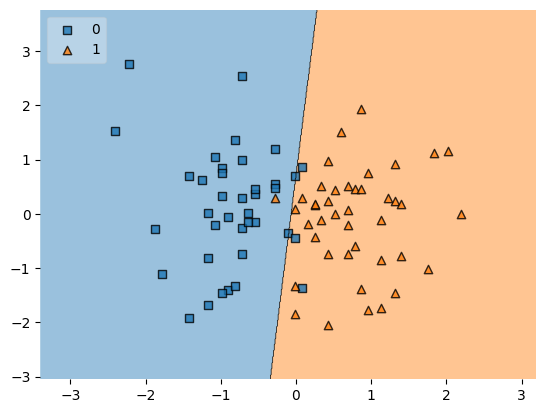

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)